In [2]:
import torch 
from torch .utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms
import pandas as pd
import os
import pickle
import cv2
import matplotlib.pyplot as plt
from torch import nn
import gc

In [2]:
data=pd.read_csv('./MRI_dataset/metadata.csv')

In [3]:
data.head()

,examId,seriesNo,aclDiagnosis,kneeLR,roiX,roiY,roiZ,roiHeight,roiWidth,roiDepth,volumeFilename
0,329637,8,0,1,139,184,14,74,72,3,329637-8.pck
1,390116,9,0,0,113,105,10,83,98,6,390116-9.pck
2,404663,8,1,1,120,117,15,101,115,2,404663-8.pck
3,406320,9,0,0,117,124,12,91,80,3,406320-9.pck
4,412857,8,0,1,122,105,14,83,98,4,412857-8.pck


In [4]:
class MRIdataset_YOLO(Dataset):
    def __init__(self,rootdir,metadata,target_size=(320,320),transform=None,target_transform=None,max_files=50):
        self.rootdir=rootdir
        self.data=pd.read_csv(metadata)
        self.transform=transform
        self.target_transform=target_transform
        self.target_size=target_size
        self.max_files=max_files
        volumes=self.data['volumeFilename'].unique()[:self.max_files]
        self.volumes_data=self.data[self.data['volumeFilename'].isin(volumes)]
        self.samples=[]
        for _,row in self.volumes_data.iterrows():
            pickle_file_root=os.path.join(self.rootdir,row['volumeFilename'])
            with open (pickle_file_root,'rb') as f:
                slices=pickle.load(f)
            num_slices=slices.shape[0]
            z_start=row['roiZ']
            depth=row['roiDepth']
            for slice in range(z_start,z_start+depth):
                image=slices[slice,:,:]
                self.samples.append((image,(row['roiX'],row['roiY'],row['roiWidth'],row['roiHeight'])))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        image=self.samples[idx][0].astype(np.float32)
        label=self.samples[idx][1]
        #Normalize image and resize
        image=cv2.resize(image,self.target_size,interpolation=cv2.INTER_LINEAR)
        if self.transform:
            image=self.transform(image)
        if self.target_transform:
            label=self.target_transform(label)
        return image,label

In [12]:
dataset_test=MRIdataset_YOLO(rootdir='./MRI_dataset/volumetric_data/',metadata='./MRI_dataset/metadata.csv',max_files=1)
print(f"Size of dataset: {len(dataset_test)}")
image_test,label_test=dataset_test[2]
print(f'Image shape: {image_test.shape}, Label: {label_test}')
print(f"image type: {type(image_test)}, label type: {type(label_test)}")

Size of dataset: 3
Image shape: (320, 320), Label: (139, 184, 72, 74)
image type: <class 'numpy.ndarray'>, label type: <class 'tuple'>


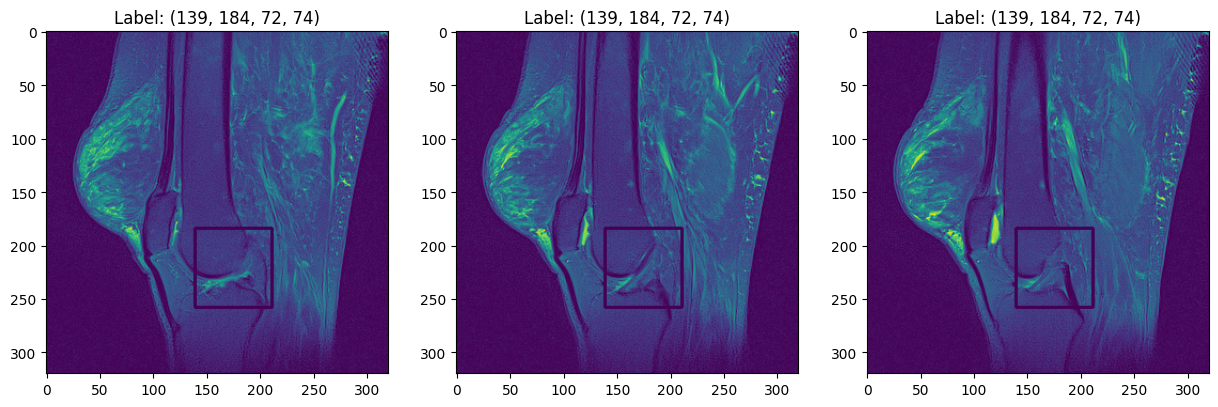

In [25]:
cv2.rectangle(image_test,pt1=(label_test[0],label_test[1]),pt2=(label_test[0]+label_test[2],label_test[1]+label_test[3]),color=(0,0,255),thickness=2)
figure = plt.figure(figsize=(15,7))
for i in range(len(dataset_test)):
    img, label = dataset_test[i]
    ax = figure.add_subplot(1, 3, i + 1)
    ax.set_title(f"Label: {label}")
    cv2.rectangle(img, pt1=(label[0], label[1]), pt2=(label[0] + label[2], label[1] + label[3]), color=(0, 0, 255), thickness=2)
    ax.imshow(img)


In [1]:
import torch
import torch.nn as nn

class LigamentIsolationCNN(nn.Module):
    def __init__(self, para):
        super(LigamentIsolationCNN, self).__init__()
        self.input_channel = para['input_channel']
        self.input_size = para['input_size']
        self.num_classes = para['num_classes']

        self.features = nn.Sequential(
            # 1️⃣ First Block
            nn.Conv2d(self.input_channel, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 2️⃣ Second Block
            nn.Conv2d(64, 192, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 3️⃣ Third Block
            nn.Conv2d(192, 128, kernel_size=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 4️⃣ Fourth Block
            *self.loop_conv_block(512, 256, 4),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 5️⃣ Fifth Block
            *self.loop_conv_block(1024, 512, 2),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            *self.loop_conv_block(1024, 512, 4)
        )

        # 6️⃣ Fully Connected + Output
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._get_flattened_size(), 4096),
            nn.ReLU(),
            nn.Linear(4096, 7 * 7 * 11),
            nn.Sigmoid()
        )

    def loop_conv_block(self, in_channels, mid_channels, n):
        layers = []
        for _ in range(n):
            layers += [
                nn.Conv2d(in_channels, mid_channels, kernel_size=1),
                nn.BatchNorm2d(mid_channels),
                nn.ReLU(),
                nn.Conv2d(mid_channels, in_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(),
            ]
        return layers

    def _get_flattened_size(self):
        with torch.no_grad():
            x = torch.randn(1, self.input_channel, *self.input_size)
            x = self.features(x)
            return x.flatten(1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        x = x.view(-1, 7, 7, 11)
        return x


if __name__ == "__main__":
    para = {
        'input_channel': 1,
        'input_size': (320, 320),
        'num_classes': 1
    }
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    with torch.no_grad():
        model = LigamentIsolationCNN(para).to(device)
        x = torch.randn(1, 1, 320, 320).to(device)
        y = model(x)
        print("✅ Output shape:", y.shape)  # Expect [1, 7, 7, 11]

        # 🧠 Count parameters
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\n🧩 Total parameters: {total_params:,}")
        print(f"🎯 Trainable parameters: {trainable_params:,}")
        print(f"💾 Model size ≈ {total_params * 4 / 1e6:.2f} MB (FP32)")


✅ Output shape: torch.Size([1, 7, 7, 11])

🧩 Total parameters: 1,732,779,227
🎯 Trainable parameters: 1,732,779,227
💾 Model size ≈ 6931.12 MB (FP32)
